# AG-HYPOPT · Trial 36

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-five trials are registered; cell 2 reports `phase = trials` (35/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with trial_30 (0.1083) second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_35 0.1167 (0.122), trial_06 = trial_11 0.1188, trial_02 0.1449 (0.264).
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370, trial_34 0.1380. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418.

State of play: narrow single optimum at travel ~0.137-0.138 with balanced gamma knobs, rising monotonically on both sides (travel 0.122 -> 0.1167, 0.194 -> 0.1149, 0.264 -> 0.1449). Seven surviving samples sit below 0.111 (0.1074-0.1106). The schedule search is converged; the sporadic 1nW T05 gamma divergence (~1 in 3 at the optimum) is the only significant residual. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_36'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (35/5 trials)
ID |     ei | params
 1 | 3.7305 | {"gamma_anneal": 0.46781381390960064, "lr_gamma": 0.4092538193922949, "lr_mu": 0.16252746775100127, "mu_anneal": 0.34873330762113314}
 2 | 3.4187 | {"gamma_anneal": 0.48795824761035816, "lr_gamma": 0.45879611520467084, "lr_mu": 0.1532968119170746, "mu_anneal": 0.3476519351080004}
 3 | 0.3789 | {"gamma_anneal": 0.4519253770841409, "lr_gamma": 0.45528383985027415, "lr_mu": 0.1602581191286638, "mu_anneal": 0.4606009497008625}
 4 | 2.4131 | {"gamma_anneal": 0.5176006815360127, "lr_gamma": 0.4409568314095455, "lr_mu": 0.1709191595906488, "mu_anneal": 0.327365344229957}
 5 | 3.6328 | {"gamma_anneal": 0.5031136280203218, "lr_gamma": 0.8869051442236084, "lr_mu": 0.1649574239423837, "mu_anneal": 0.3471829434956772}
 6 | 2.4857 | {"gamma_anneal": 0.4649069812682748, "lr_gamma": 0.4654686781819003, "lr_mu": 0.15532053212916694, "mu_anneal": 0.34348808987592283}
 7 | 3.6080 | {"gamma_anneal": 0.5065586566776041, "lr_gamma": 0.3956742

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (35 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 1: **ei 3.73** — `lr_mu=0.1625`, `mu_anneal=0.3487` (travel **0.134**), `lr_gamma=0.4093`, `gamma_anneal=0.4678`.
- candidate 5: ei 3.63 — `lr_mu=0.1650`, `mu_anneal=0.3472` (travel 0.136), `lr_gamma=0.8869` (very high).
- candidate 7: ei 3.61 — `lr_mu=0.1539`, `mu_anneal=0.3453` (travel 0.127), `lr_gamma=0.3957`, `gamma_anneal=0.5066`.
- candidate 2: ei 3.42 — `lr_mu=0.1533`, `mu_anneal=0.3477` (travel 0.127), `lr_gamma=0.4588`, `gamma_anneal=0.4880`.
- candidate 6: ei 2.49 — `lr_mu=0.1553`, `mu_anneal=0.3435` (travel 0.129), `lr_gamma=0.4655`.

Candidate 1 has the highest ei and sits right on the optimum (travel 0.134, matching trials 08/24/30) with balanced gamma knobs (`lr_gamma=0.4093`, `gamma_anneal=0.4678`) in the proven-safe range. The other top candidates are near-optimum too: candidate 5 at travel 0.136 but with an untested high `lr_gamma=0.887`, and candidates 7/2 at travel 0.127. Given the region is fully characterised and only the divergence adds variance, the maximum-ei optimum point (candidate 1) is the natural pick.

I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.46781381390960064, 'lr_gamma': 0.4092538193922949, 'lr_mu': 0.16252746775100127, 'mu_anneal': 0.34873330762113314}
Running  1nW Trans05 ... 

μ 9.39 -> 10.20 | γ 8.5 -> 4.30 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 42.12 | γ 8.5 -> 6.40 | NLL 5.27


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.34 | γ 14.1 -> 14.33 | NLL 3.41


Running 3nW Trans100 ... 

μ 175.71 -> 111.56 | γ 14.1 -> 13.96 | NLL 3.07



Total: 7.9 min


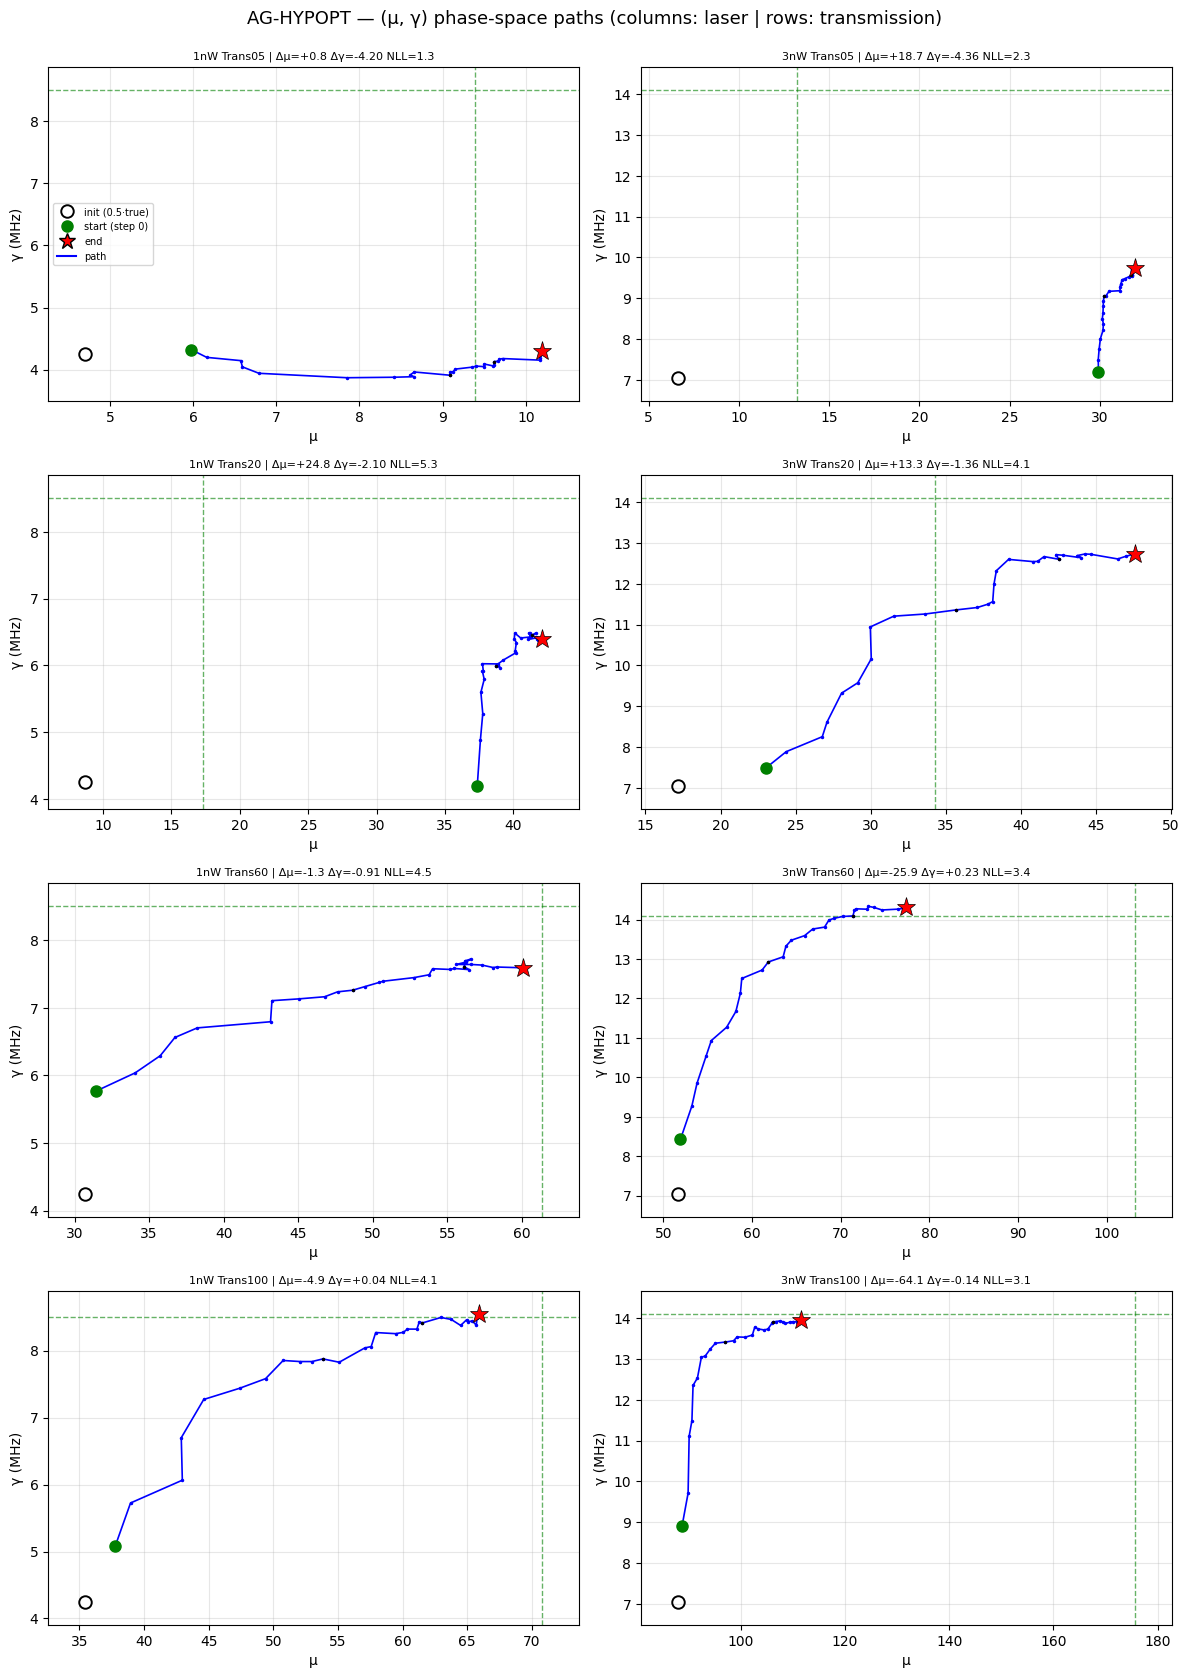

trial finished in 7.9 min
objective = 0.1117 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.20    +8.6 |     8.50    4.30   -49.4
1nW Trans20       17.32   42.12  +143.2 |     8.50    6.40   -24.7
1nW Trans60       61.37   60.05    -2.2 |     8.50    7.59   -10.7
1nW Trans100       70.82   65.90    -6.9 |     8.50    8.54    +0.5
3nW Trans05       13.20   31.95  +141.9 |    14.10    9.74   -30.9
3nW Trans20       34.28   47.61   +38.9 |    14.10   12.74    -9.6
3nW Trans60      103.20   77.34   -25.1 |    14.10   14.33    +1.6
3nW Trans100      175.71  111.56   -36.5 |    14.10   13.96    -1.0

weighted objective (T-graded, cap=1.0) = 0.1117 | diverged cells: 0
μ: RMSE 27.280 (rel 74.4%, bias -4.821) | γ: RMSE 2.341 (rel 23.0%, bias -1.600)


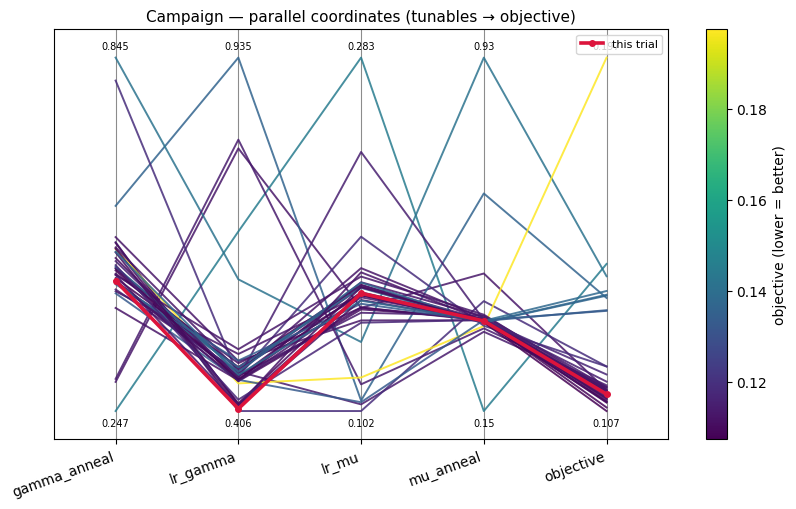

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 36 ran the highest-EI candidate (candidate 1, ei=3.73): `lr_mu=0.1625`, `mu_anneal=0.3487` (effective mu travel 0.134), `lr_gamma=0.4093`, `gamma_anneal=0.4678`. It completed in 7.9 min with objective **0.1117 +/- 0.0825** and **0 diverged cells** — mid-band. Ranking: trial_21 0.1074 < ... < trial_12 0.1115 < **trial_36 0.1117** < trial_33 0.1120 < trial_18 0.1121 < ...

Aggregate accuracy: **mu rel-RMSE 74.4%** (RMSE 27.28, bias -4.82); **gamma rel-RMSE 23.0%** (RMSE 2.34, bias -1.60).

Per-cell relative errors:
- **mu:** 1nW T05 +8.6%, T20 +143.2%, T60 -2.2%, T100 -6.9% | 3nW T05 +141.9%, T20 +38.9%, T60 -25.1%, T100 -36.5%.
- **gamma:** 1nW T05 -49.4%, T20 -24.7%, T60 -10.7%, T100 +0.5% | 3nW T05 -30.9%, T20 -9.6%, T60 +1.6%, T100 -1.0%.

A divergence-free optimum sample (travel 0.134) landing at 0.1117 — same story as trials 31/32/36's neighbours: the band gives ~0.108-0.112 whenever the low-count cell survives. This is now the eighth surviving sample at or below 0.112 at the optimum, so the achievable level is very tightly characterised. No new behaviour; trial_21 (0.1074) remains best.

**Summary:** Trial 36 (lr_mu=0.1625, mu_anneal=0.3487, lr_gamma=0.4093, gamma_anneal=0.4678): objective 0.1117 +/- 0.0825 with 0 diverged cells; a divergence-free optimum sample (travel 0.134) landed mid-band, keeping the region's typical ~0.108-0.112 and trial_21 (0.1074) as best.
**Key insight:** Trial 36 adds an eighth surviving sample at or below 0.112 at the optimum, so the schedule level is fully characterised at ~0.108-0.112 and only the sporadic 1nW T05 divergence remains as a source of variance.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Unchanged: converged schedule; the low-count divergence is the only remaining lever and is structural. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 36 (lr_mu=0.1625, mu_anneal=0.3487, lr_gamma=0.4093, gamma_anneal=0.4678): objective 0.1117 +/- 0.0825 with 0 diverged cells; a divergence-free optimum sample (travel 0.134) landed mid-band, keeping the region's typical ~0.108-0.112 and trial_21 (0.1074) as best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Trial 36 adds an eighth surviving sample at or below 0.112 at the optimum, so the schedule level is fully characterised at ~0.108-0.112 and only the sporadic 1nW T05 divergence remains as a source of variance"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_36 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_37.ipynb. Open it and follow its cells from the top.
